# 04 — Feature Set 2
> **Chương 6.4** — Target Rate Encoding (TRE) và Computable Features

Feature Set 2 cải tiến Feature Set 1 bằng hai kỹ thuật:
1. **Target Rate Encoding (TRE)** thay thế One-Hot Encoding — giữ thông tin ordinal, tránh bùng nổ chiều.
2. **Computable Features** — feature tổ hợp từ các thuộc tính có sẵn (area × density, |lat|, triple_per_attr, ...).

| Step | Kỹ thuật | Lý do |
|------|----------|-------|
| TRE  | Smoothed mean target encoding | Giảm chiều từ ~200 → 2; tránh high-cardinality OHE |
| Computable | Interaction & derived features | Thêm tín hiệu mà model khó học trực tiếp |
| So sánh | Set1 vs Set2 | Đo mức cải thiện RMSE |

In [10]:
%run /content/Seminar-Pattern-Recognition/setup_colab.py

🔄 Repo đã có, pulling latest...
✅ Pull xong
📁 Working dir: /content/Seminar-Pattern-Recognition
🐍 src/ đã thêm vào sys.path
📂 Thư mục data/ models/ reports/ sẵn sàng
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive đã mount tại /content/drive/MyDrive/
📂 Drive folder: /content/drive/MyDrive/Seminar-Pattern-Recognition

🔄 Sync Drive → /content/ ...
✅ Sync xong (0 file(s) total)

📦 Cài thư viện...
✅ Cài xong
🖥️  GPU: Tesla T4, 15360 MiB

🚀 Setup hoàn tất! Bắt đầu chạy notebook.


<Figure size 768x576 with 0 Axes>

## 0. Import & Load

In [11]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.impute import SimpleImputer
import warnings; warnings.filterwarnings('ignore')

# Colab: setup_colab.py đã chạy → CWD = /content/Seminar-Pattern-Recognition
# Local: CWD có thể là notebooks/ → dùng .parent
PROJECT_ROOT = Path(os.getcwd())
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from feature_engineering import (
    rare_category_grouper,
    log_transform_cols,
    target_rate_encoding,
    add_computable_features,
    build_feature_matrix,
)
from evaluation import evaluate_cv, print_cv_results, plot_feature_importance

RAW_DIR     = PROJECT_ROOT / 'data' / 'raw'
FEAT_DIR    = PROJECT_ROOT / 'data' / 'features'
REPORTS_DIR = PROJECT_ROOT / 'reports'
FEAT_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
SEED = 42

df = pd.read_csv(RAW_DIR / 'wikicities_raw.csv')
df = df.dropna(subset=['population']).copy()
df['log_population'] = np.log1p(df['population'])
y = df['log_population']
print(f' Loaded: {df.shape}')

 Loaded: (5826, 19)


## 1. Log transform & Computable Features

In [12]:
LOG_COLS = ['area', 'numTriples', 'abstractLen', 'populationDensity']
df_fe = log_transform_cols(df, LOG_COLS)

df_fe = add_computable_features(df_fe)

new_cols = ['area_x_density', 'log_area_x_density', 'lat_abs', 'lon_abs',
            'has_region', 'is_recent', 'triple_per_attr', 'log_triple_per_attr']

print('Computable features được tạo:')
for col in new_cols:
    if col in df_fe.columns:
        print(f'  {col:30s}: non-null={df_fe[col].notna().sum():,}')

Computable features được tạo:
  area_x_density                : non-null=5,826
  log_area_x_density            : non-null=5,826
  lat_abs                       : non-null=5,720
  lon_abs                       : non-null=5,720
  has_region                    : non-null=5,826
  is_recent                     : non-null=5,826
  triple_per_attr               : non-null=2,000
  log_triple_per_attr           : non-null=2,000


## 2. Target Rate Encoding (TRE)

> **Tại sao dùng TRE thay OHE?**
> - `country_name` có ~150 giá trị duy nhất → OHE tạo ra ~150 cột sparse
> - TRE ánh xạ mỗi category thành 1 số thực (mean target có smoothing) → chỉ 2 cột
> - Công thức: `encoded = (n_i × mean_i + m × global_mean) / (n_i + m)` với m=10
> - Tránh data leakage: tính stats trên fold train, áp dụng lên fold val

TRE values — Top 10 country_name_tre:
                    country_name  country_name_tre
                           China         13.953920
                          Turkey         13.257906
                         Nigeria         12.877771
                        Malaysia         12.776389
                       Indonesia         12.691935
                         Somalia         12.663357
            United_Arab_Emirates         12.587845
                    Saudi_Arabia         12.578802
                           Sudan         12.575617
Democratic_Republic_of_the_Congo         12.516882


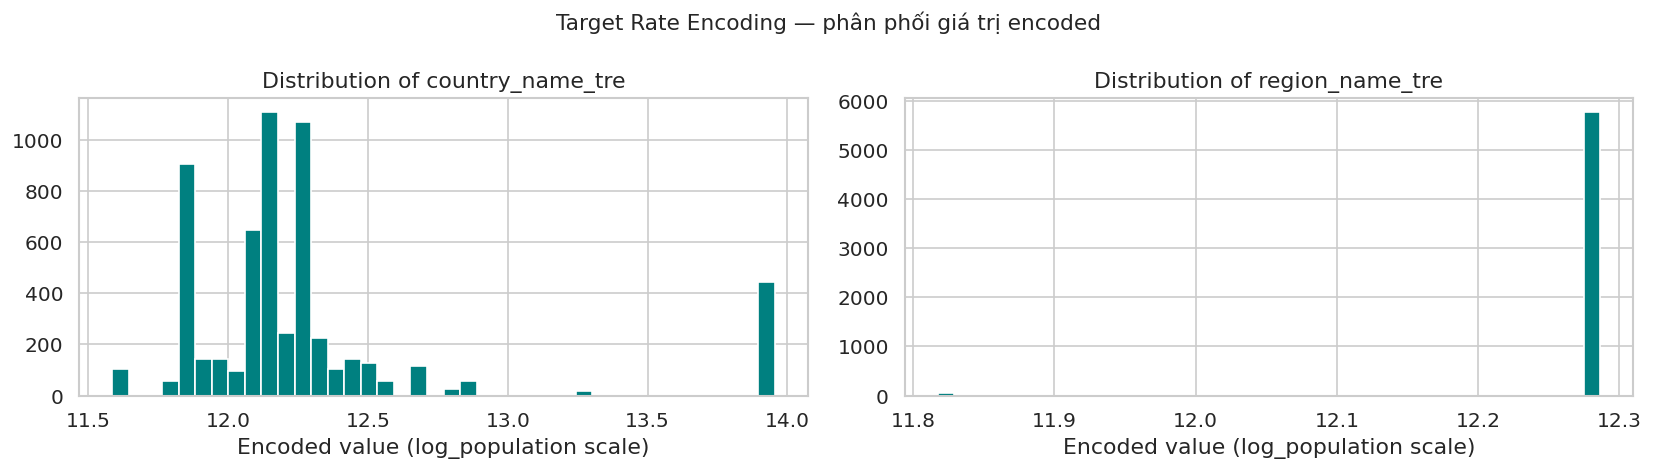

In [13]:
CAT_COLS = ['country_name', 'region_name']
MIN_FREQ = 10

for col in CAT_COLS:
    df_fe[col] = rare_category_grouper(df_fe[col], min_freq=MIN_FREQ)

# TRE trên toàn bộ dataset (dành cho khám phá — khi train dùng CV-aware TRE)
df_tre = target_rate_encoding(
    df_train=df_fe,
    df_apply=df_fe,
    cat_cols=CAT_COLS,
    target_col='log_population',
    smoothing=10.0,
)

print('TRE values — Top 10 country_name_tre:')
print(
    df_tre[['country_name', 'country_name_tre']]
    .drop_duplicates()
    .sort_values('country_name_tre', ascending=False)
    .head(10)
    .to_string(index=False)
)

# Phân phối TRE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, [f'{c}_tre' for c in CAT_COLS]):
    if col in df_tre.columns:
        ax.hist(df_tre[col].dropna(), bins=40, color='teal', edgecolor='white')
        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel('Encoded value (log_population scale)')
plt.suptitle('Target Rate Encoding — phân phối giá trị encoded', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'tre_distribution.png', bbox_inches='tight')
plt.show()

## 3. Xây dựng Feature Set 2

In [14]:
NUM_COLS_SET2 = [
    'log_area', 'elevation', 'lat', 'lon', 'lat_abs',
    'log_populationDensity', 'log_area_x_density',
    'foundingYear', 'is_recent',
    'numAttributes', 'log_numTriples', 'log_triple_per_attr',
    'hasAbstract', 'log_abstractLen',
    'has_region',
]
TRE_COLS = ['country_name_tre', 'region_name_tre']

X_set2 = build_feature_matrix(df_tre, NUM_COLS_SET2, TRE_COLS)

print(f' Feature Set 2: {X_set2.shape[0]:,} rows × {X_set2.shape[1]} features')
print(f'   Numeric: {len(NUM_COLS_SET2)} | TRE: {len(TRE_COLS)}')
print(f'   NaN còn lại: {X_set2.isna().sum().sum()}')

 Feature Set 2: 5,826 rows × 17 features
   Numeric: 15 | TRE: 2
   NaN còn lại: 5826


## 4. So sánh Set 1 vs Set 2 — Random Forest

 Feature Set 1 loaded: (5826, 90)

──────────────────────────────────────────────────
  Feature Set 2 (TRE + computable)
──────────────────────────────────────────────────
  RMSE : 0.7265 ± 0.0394
  MAE  : 0.5121 ± 0.0138
  R²   : 0.6056 ± 0.0552

──────────────────────────────────────────────────
  Feature Set 1 (OHE baseline)
──────────────────────────────────────────────────
  RMSE : 0.7389 ± 0.0357
  MAE  : 0.5265 ± 0.0131
  R²   : 0.5923 ± 0.0530


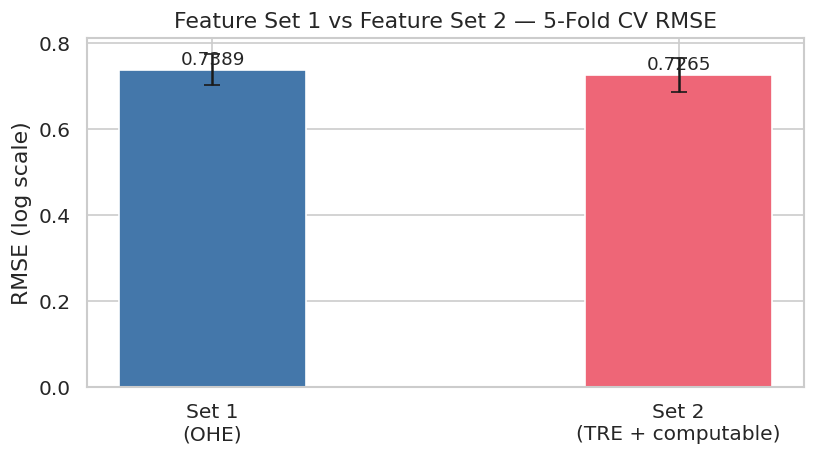


 Cải thiện RMSE: +0.0124


In [15]:
rf = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)

# Load Set 1 nếu đã có
feat_set1_path = FEAT_DIR / 'feature_set1.csv'
if feat_set1_path.exists():
    X_set1_full = pd.read_csv(feat_set1_path)
    y_set1 = X_set1_full.pop('log_population')
    X_set1 = X_set1_full
    print(f' Feature Set 1 loaded: {X_set1.shape}')
else:
    print('  feature_set1.csv chưa có — hãy chạy notebook 03 trước')
    X_set1, y_set1 = None, None

res2 = evaluate_cv(rf, X_set2, y, cv=5, seed=SEED)
print_cv_results(res2, 'Feature Set 2 (TRE + computable)')

if X_set1 is not None:
    res1 = evaluate_cv(rf, X_set1, y_set1, cv=5, seed=SEED)
    print_cv_results(res1, 'Feature Set 1 (OHE baseline)')

    labels    = ['Set 1\n(OHE)', 'Set 2\n(TRE + computable)']
    rmse_vals = [res1['rmse_mean'], res2['rmse_mean']]
    errs      = [res1['rmse_std'],  res2['rmse_std']]

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(labels, rmse_vals, yerr=errs, capsize=5,
                  color=['#4477aa', '#ee6677'], width=0.4)
    ax.set_ylabel('RMSE (log scale)')
    ax.set_title('Feature Set 1 vs Feature Set 2 — 5-Fold CV RMSE')
    for bar, val in zip(bars, rmse_vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11)
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'set1_vs_set2_rmse.png', bbox_inches='tight')
    plt.show()
    print(f'\n Cải thiện RMSE: {res1["rmse_mean"] - res2["rmse_mean"]:+.4f}')

## 5. Feature Importance — Set 2

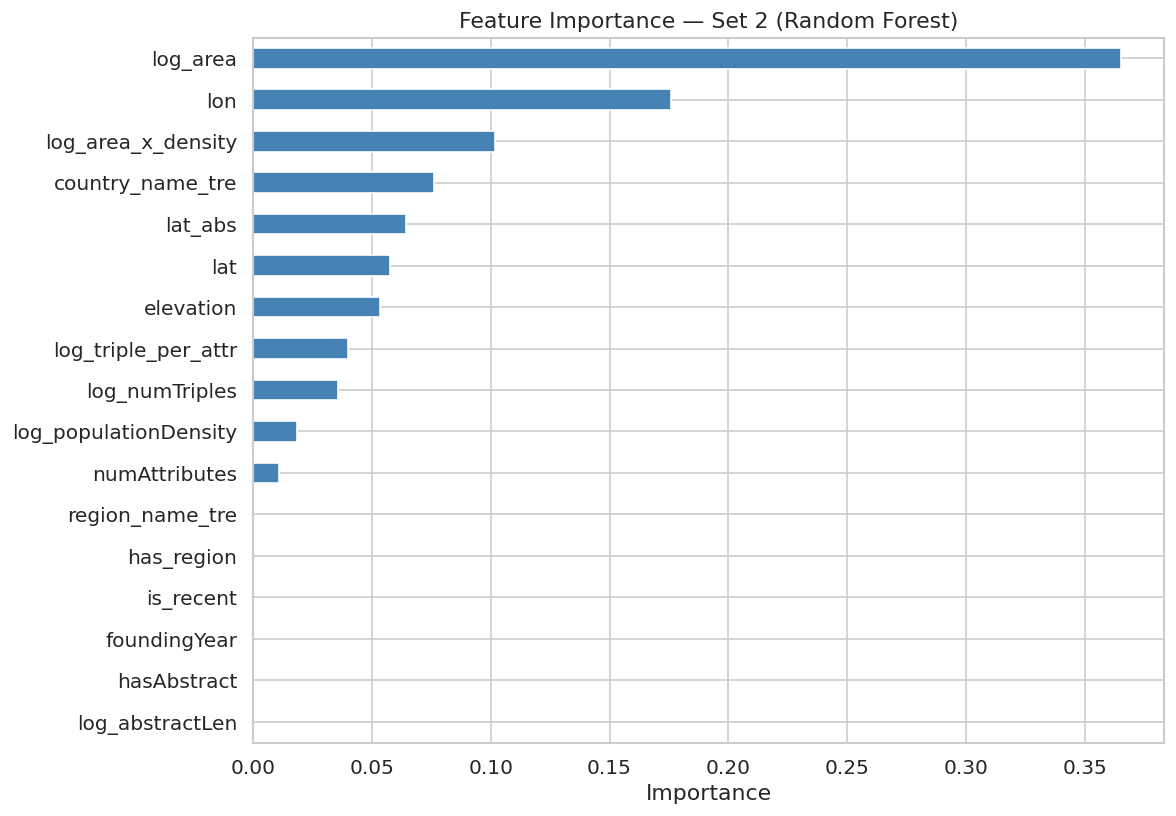


Top 10 features:
log_area                 0.365162
lon                      0.175959
log_area_x_density       0.101839
country_name_tre         0.076074
lat_abs                  0.064579
lat                      0.057754
elevation                0.053554
log_triple_per_attr      0.039804
log_numTriples           0.035658
log_populationDensity    0.018532


In [16]:
rf.fit(X_set2, y)
importance = pd.Series(rf.feature_importances_, index=X_set2.columns)
importance = importance.sort_values(ascending=False)

plot_feature_importance(
    importance, top_n=20,
    title='Feature Importance — Set 2 (Random Forest)',
    save_path=REPORTS_DIR / 'feature_importance_set2.png'
)

print('\nTop 10 features:')
print(importance.head(10).to_string())

## 6. TRE Smoothing Sensitivity

  smoothing=   1: RMSE = 0.7270 ± 0.0403
  smoothing=   5: RMSE = 0.7269 ± 0.0394
  smoothing=  10: RMSE = 0.7265 ± 0.0394
  smoothing=  20: RMSE = 0.7275 ± 0.0401
  smoothing=  50: RMSE = 0.7285 ± 0.0427
  smoothing= 100: RMSE = 0.7280 ± 0.0437


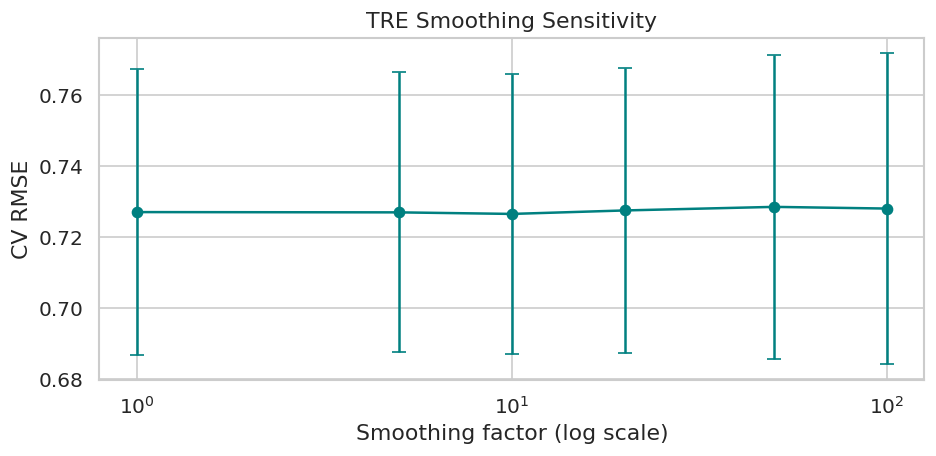

In [17]:
smoothing_values = [1, 5, 10, 20, 50, 100]
smoothing_results = []

for m in smoothing_values:
    df_tmp = target_rate_encoding(
        df_train=df_fe, df_apply=df_fe,
        cat_cols=CAT_COLS, target_col='log_population', smoothing=m
    )
    X_tmp = build_feature_matrix(df_tmp, NUM_COLS_SET2, TRE_COLS)
    res   = evaluate_cv(rf, X_tmp, y, cv=5, seed=SEED)
    smoothing_results.append({'smoothing': m, 'rmse': res['rmse_mean'], 'std': res['rmse_std']})
    print(f'  smoothing={m:4d}: RMSE = {res["rmse_mean"]:.4f} ± {res["rmse_std"]:.4f}')

sm_df = pd.DataFrame(smoothing_results)
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(sm_df['smoothing'], sm_df['rmse'], yerr=sm_df['std'],
            marker='o', color='teal', capsize=4)
ax.set_xscale('log')
ax.set_xlabel('Smoothing factor (log scale)')
ax.set_ylabel('CV RMSE')
ax.set_title('TRE Smoothing Sensitivity')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'tre_smoothing_sensitivity.png', bbox_inches='tight')
plt.show()

## 7. Lưu Feature Set 2

In [18]:
X_set2_save = X_set2.copy()
X_set2_save['log_population'] = y.values
X_set2_save.to_csv(FEAT_DIR / 'feature_set2.csv', index=False)

importance.to_csv(FEAT_DIR / 'feature_importance_set2.csv', header=['importance'])

print(f' feature_set2.csv          : {X_set2_save.shape}')
print(f' feature_importance_set2.csv lưu xong')
print('  Bước tiếp theo: 05_stability_final.ipynb')

 feature_set2.csv          : (5826, 18)
 feature_importance_set2.csv lưu xong
  Bước tiếp theo: 05_stability_final.ipynb
